In [37]:
import numpy as np
import pandas as pd

In [38]:
df = pd.read_csv("powerplant_data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


feature details:
|Feature|Mark|
|-------|----|
|AT|temprature|
|V|vacum|
|AP|pressure|
|RH|humidity|
|PE|produced energy (target)|

In [39]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

* no null values found

#### Data and Split

In [40]:
X = df.drop("PE", axis=1)
y = df["PE"]

y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [41]:
#Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42
)

df.shape

(9568, 5)

#### Scaling

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]],
      shape=(1914, 4))

#### Tensors

In [43]:
#Tensors
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)


#### Batchs

In [44]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

#batch_size defines no of samples for each bathc of data
#shuffle, shuffles dataset before creating batches (to get randomn samples in a batch instead of sequential samples)


### ANN

In [45]:
#Define our ANN Model
class ANN_model(nn.Module):
    def __init__(self):
        super(ANN_model, self).__init__()
        #confusion: why we call super

        #neural network arch
        self.model = nn.Sequential(
            #hidden layer-I
            nn.Linear(X_train.shape[1], 6), #rows, coumns
            #linear: x1w1 + b
            nn.ReLU(),

            #hidden layer-II
            nn.Linear(6, 6),
            nn.ReLU(),
                
            # output layer
            nn.Linear(6, 1)
        )

    def forward(self, x):
        return self.model(x)

import torch.optim as optim

model = ANN_model()
#loss, optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

#### Train model

In [46]:
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0   # total training loss for 1 epoch (set to 0 each time for new eoch)

    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()   #sets it to zero for each time

        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = criterion(outputs, yb)   # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step()    # params update

        running_loss += loss.item()     # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    #loss for each epochh will be avg: total loss/ no of samles
    train_losses.append(epoch_train_loss)

    #Validation
    # (it works similar as testing)
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        #no gradients computations
        #we dont require grad as we are not updating bias or weights
        #it refuces space and speeds up computations
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    #saving the best model and its state
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")     #it saves the state of a model (learning parameters)
        #save model using ext: pt or pth


epoch 1/100 ==> train loss = 206110.98268229168 & val loss = 204966.953125
epoch 2/100 ==> train loss = 200948.93645833334 & val loss = 193743.3125
epoch 3/100 ==> train loss = 178378.62962239582 & val loss = 157670.109375
epoch 4/100 ==> train loss = 131486.24368489583 & val loss = 105950.21875
epoch 5/100 ==> train loss = 85298.64370117188 & val loss = 69288.9921875
epoch 6/100 ==> train loss = 58262.43452148438 & val loss = 49189.0
epoch 7/100 ==> train loss = 40851.79873046875 & val loss = 33458.55859375
epoch 8/100 ==> train loss = 26758.801000976564 & val loss = 20922.931640625
epoch 9/100 ==> train loss = 16345.237145996094 & val loss = 12415.4130859375
epoch 10/100 ==> train loss = 9778.017761230469 & val loss = 7603.9501953125
epoch 11/100 ==> train loss = 6333.398420206706 & val loss = 5243.45556640625
epoch 12/100 ==> train loss = 4587.582020823161 & val loss = 3990.779541015625
epoch 13/100 ==> train loss = 3546.615644836426 & val loss = 3138.003173828125
epoch 14/100 ==> t

### Visualisation

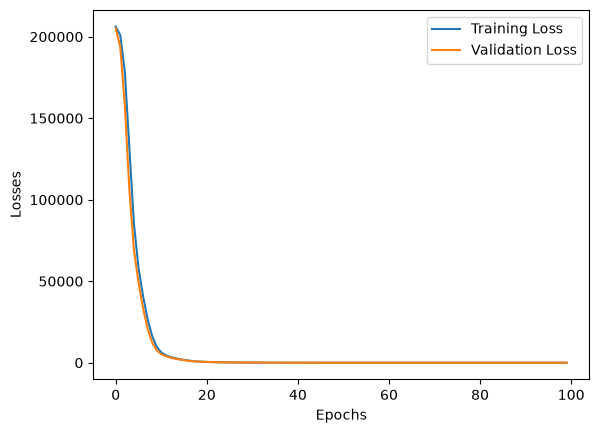

In [47]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

# plt.figure(figsize=(12,10))

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

#### Loading the best model


In [48]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

### Evaluation

In [49]:
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

from sklearn.metrics import r2_score

print("r2 score =", r2_score(y_test, test_preds))

Training MSE: 21.249486923217773
Testing MSE: 19.774778366088867
r2 score = 0.9308922542033504


In [50]:
pred_df = pd.DataFrame(test_preds.numpy(), columns=["predicted values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([pred_df, actual_df], axis=1)

,predicted values,Actual Values
0,435.686981,433.27
1,437.017670,438.16
2,461.121246,458.42
3,475.759430,480.82
4,435.734192,441.41
...,...,...
1909,451.227264,456.70
1910,431.909943,438.04
1911,467.601349,467.80
1912,431.341309,437.14


#### Dev Model

In [51]:
from pathlib import Path

model_path = Path("app/models/model.pt")
model_path.parent.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), model_path)
print(f"Saved model to {model_path}")

Saved model to app\models\model.pt
